In [3]:
from matplotlib.gridspec import GridSpec
import networkx as nx
from itertools import product
from collections import defaultdict
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import circmean
from scipy.stats import circstd
from pathlib import Path
import sys
import numpy as np
import glob
import os
from scipy.stats import iqr
from scipy.ndimage import gaussian_filter


%load_ext autoreload
%autoreload

def get_parent_dir():
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)

sys.path.append(parent_dir)
from stimulus_experiments.entrainment_experiments import *
from stimulus_experiments.entrainment_analysis import *
from stimulus_experiments.main_entrain import (
    parse_args,
    build_train_config,
    build_baseline_config,
    build_test_config,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent directory: c:\Users\HP\ModellingProjects\Olivocerebellar-circuit


## Overview run functions/contrasts

### Training:
o Fixed stimulus interval for training
o Variable stimulus interval for training
o No stimulus training / convergence

Training runs are short, should not need to be split.
ISI's to use for training:
- 120ms (flocculus) mean 
- 35ms for std, when variables ISI

### Testing:
o Fixed different mean ISI, fixed ISI trained, plastic model

o Fixed different mean ISI, fixed ISI trained, static model

o Fixed different mean ISI, variable ISI trained, plastic model

o Fixed different mean ISI, variable ISI trained, static model

o Fixed different mean ISI, no stimulus trained, plastic model

o Fixed different mean ISI, no stimulus trained, static model


#### Controls for test runs:
o Fixed same mean ISI, fixed ISI trained, static model

o No stimulus, fixed ISI trained, plastic model

o No stimulus, variable ISI trained, plastic model

### Baseline 
o Plastic model, no input

o Plastic model, fixed mean ISI

o Plastic model, variable mean ISI



## Command generators


### Training runs

In [ ]:
jobs_fixed_isi = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                                 ISI_values=None, experiment="fixed-isi", ISI_std=0.0, tag=None)
jobs_variable_isi = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                                    ISI_values=None, experiment="variable-isi", ISI_std=35.0, tag=None)
jobs_nostim = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                              ISI_values=None, experiment="nostim", ISI_std=0.0, tag=None)

In [15]:
# Fixed isi commands
for job in jobs_fixed_isi:
    print(job["command"])


python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment f

In [18]:
# Variable isi commands
for job in jobs_variable_isi:
    print(job["command"])

python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 35.0
python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 35.0
python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120

In [19]:
# Nostim commands
for job in jobs_nostim: 
    print(job["command"])

python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --

### Baseline runs

In [4]:
## Baseline runs without input
# Get commands and paths for all baseline runs
base_repl_jobs = baseline_commands(parent_dir = parent_dir, n_seeds=10, simdur= 10_000.0)
for job in base_repl_jobs:
    print(job["command"])




python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 88 --monitor-preset "plasticity_min" --simdur 10000.0 --parent-dir /home/izet/Olivocerebellar-circuit --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 89 --monitor-preset "plasticity_min" --simdur 10000.0 --parent-dir /home/izet/Olivocerebellar-circuit --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 90 --monitor-preset "plasticity_min" --simdur 10000.0 --parent-dir /home/izet/Olivocerebellar-circuit --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 91 --monitor-preset "plasticity_min" --simdur 10000.0 --parent-dir /home/izet/Oliv

### Testing runs

## Analysis & plots

### Stimulus check

In [23]:
# Load fixed isi and variable isi data
fixed_isi_paths = [job["run_path"] for job in jobs_fixed_isi]

for dataset in fixed_isi_paths:
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

       
        pf_stim_start = data["stim_pf_start"]
        io_stim_start = data["stim_io_start"]

        pf_OU = data["pf.I_OU"]
        pc_spike = data["pc.spike"]
        pc_V = data["pc.V"]
        pc_rho= data["pc.rho"]


        io_OU = data[ "io.I_OU"]
        io_spike = data["io.spike"]
        io_V = data["io.V_soma"]





        

### Baseline runs / replication of Elias' paper

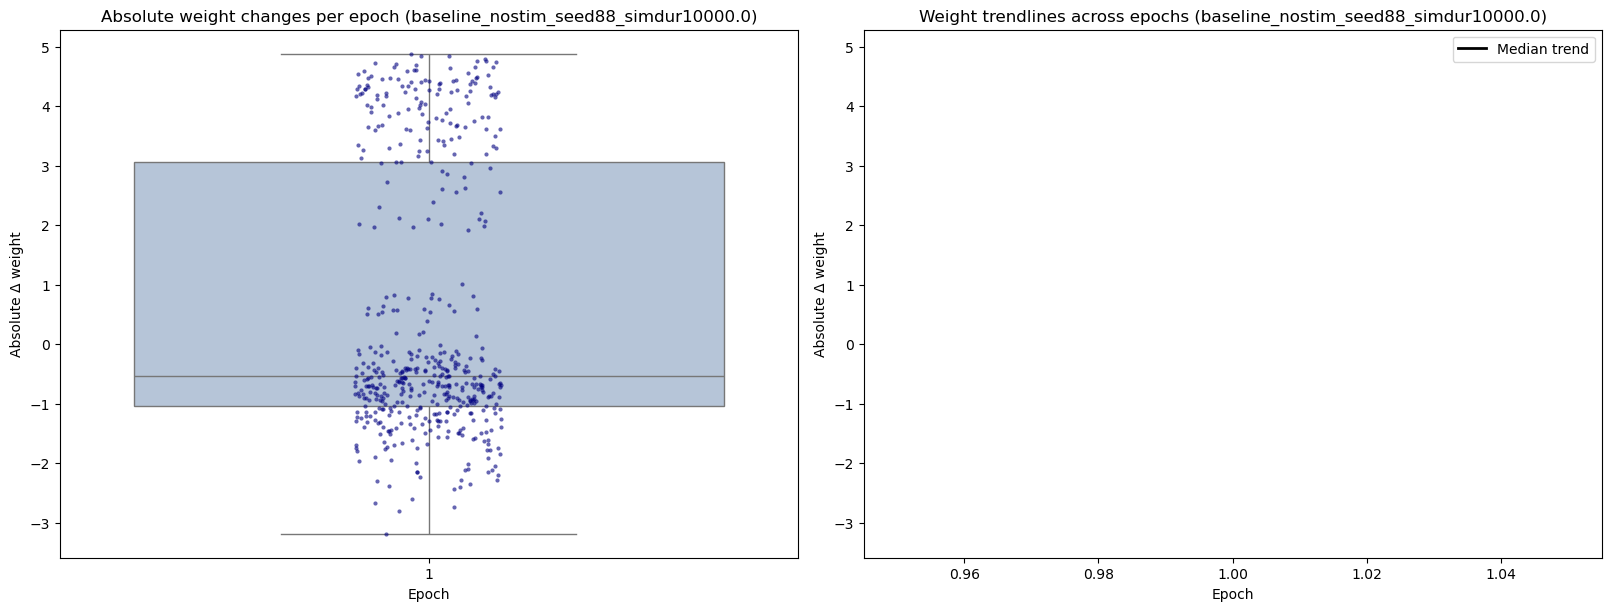

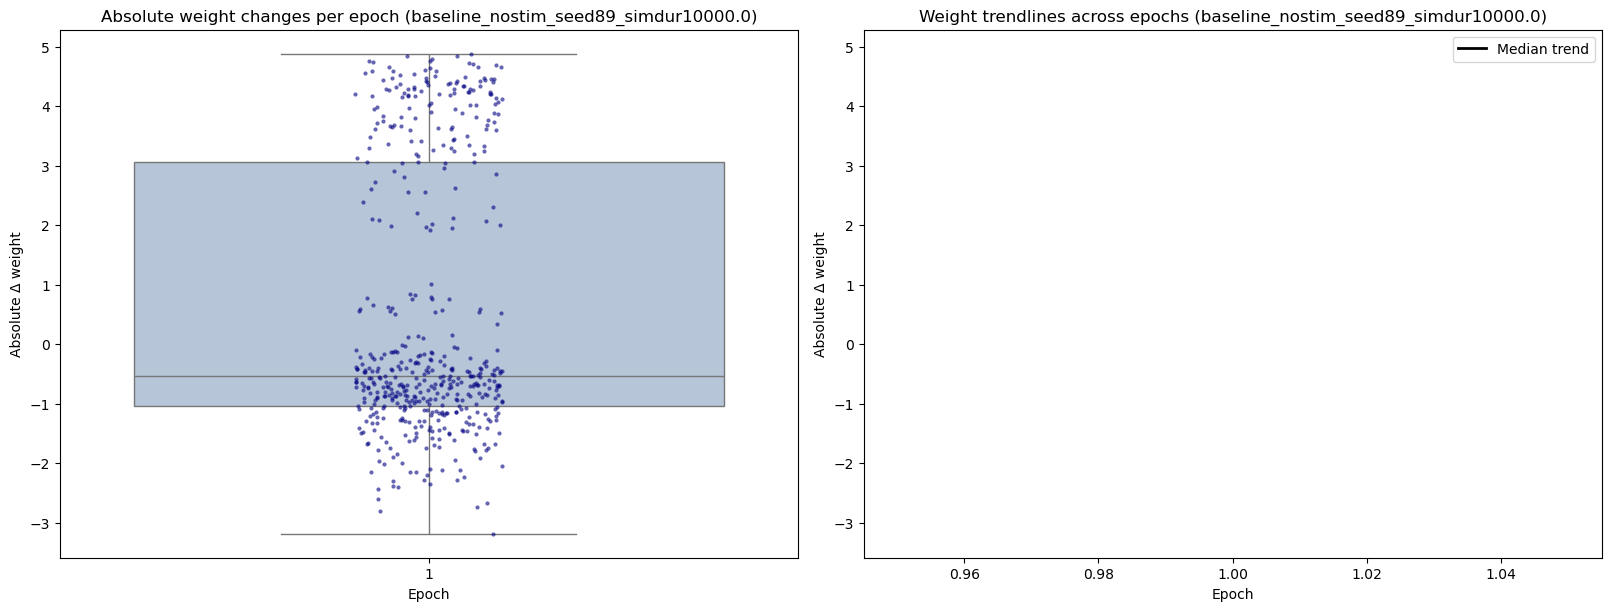

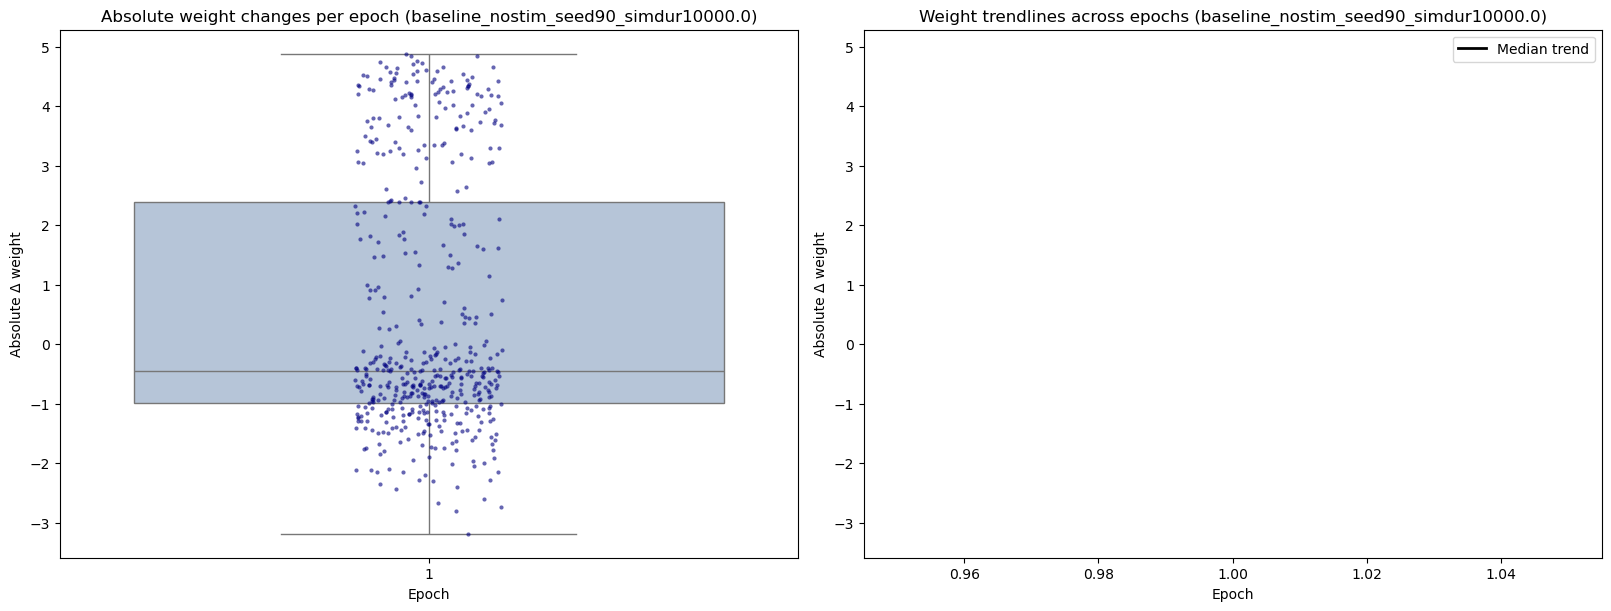

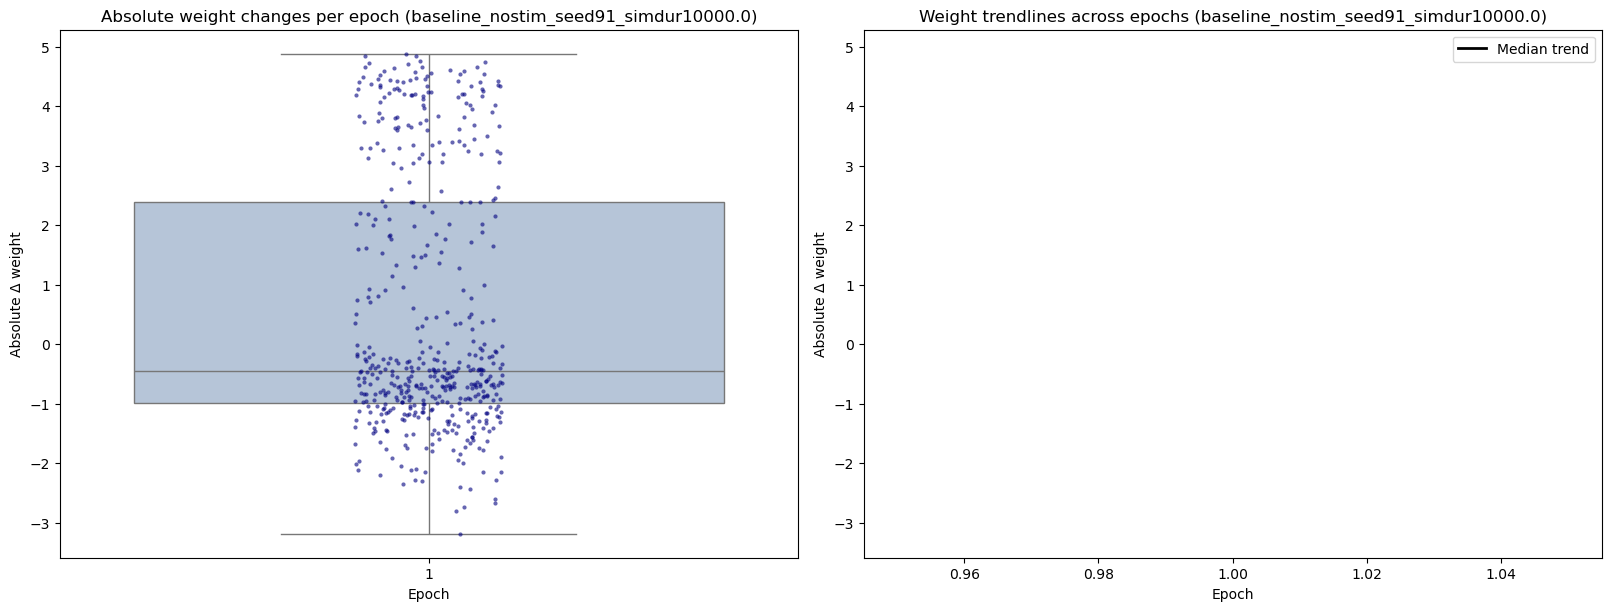

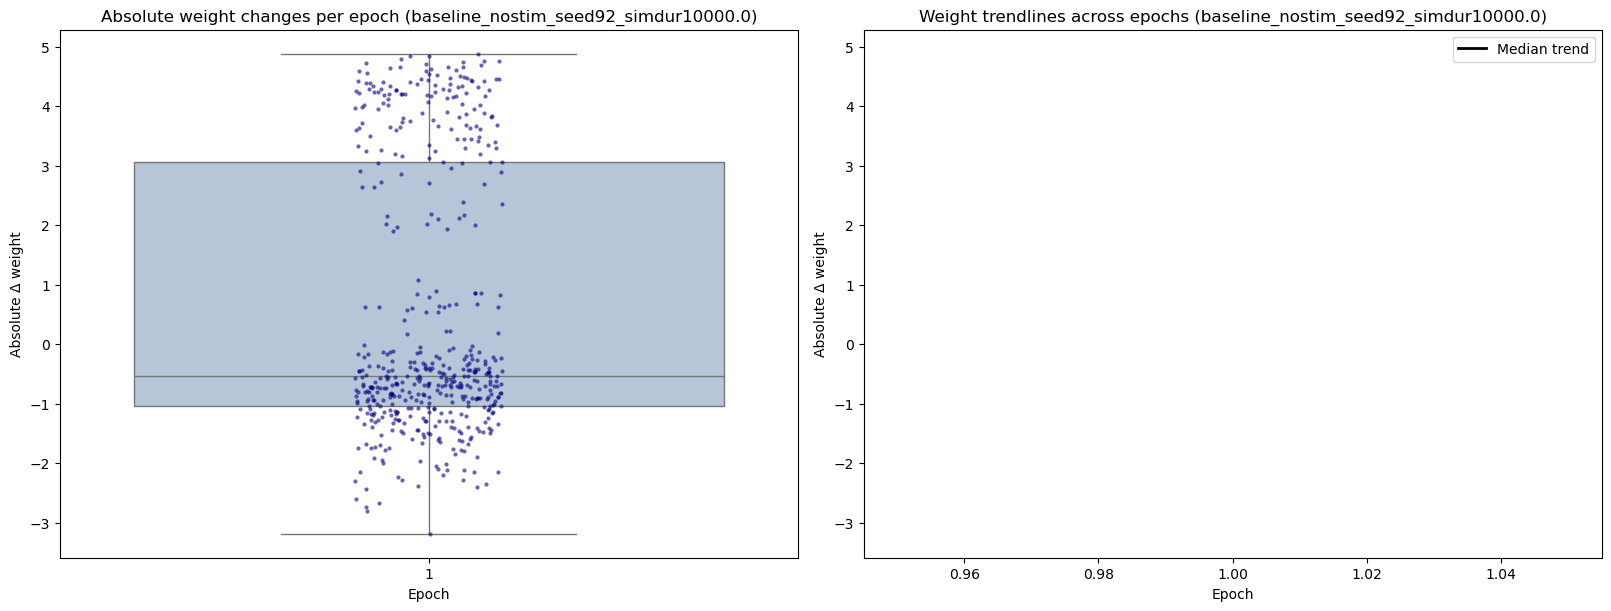

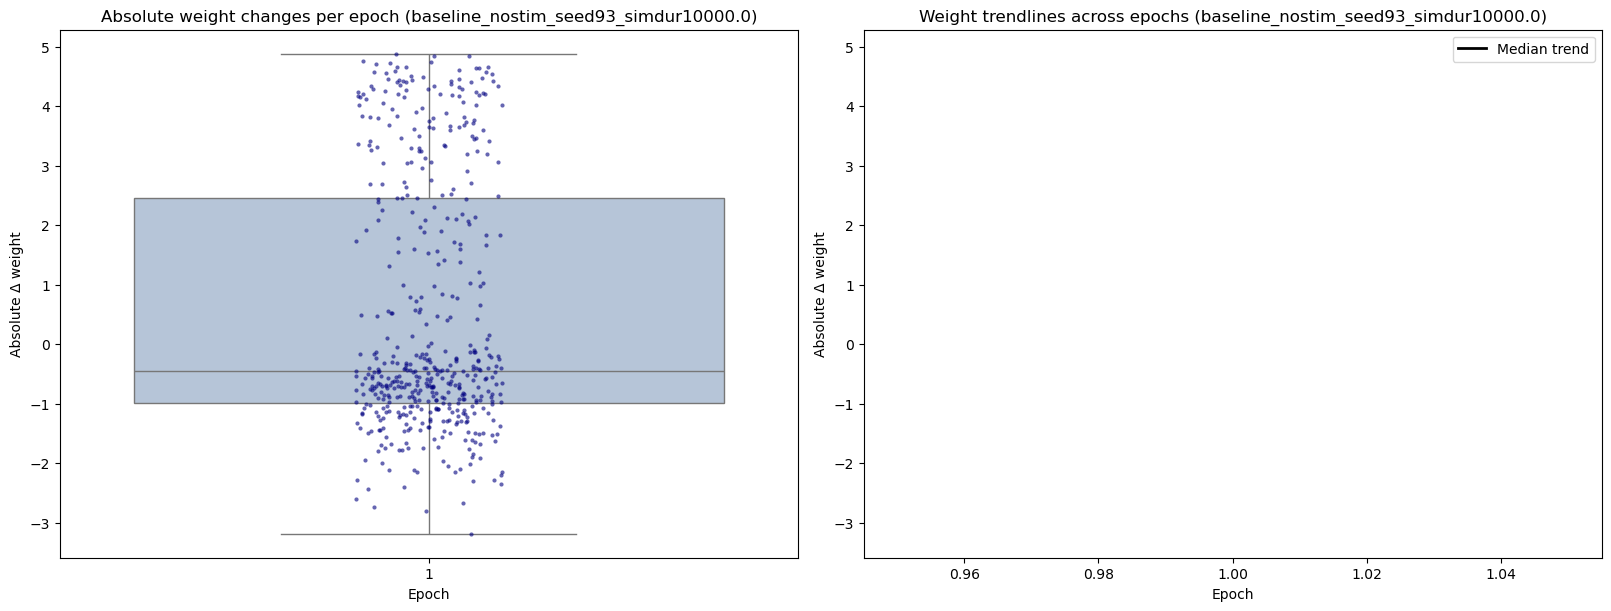

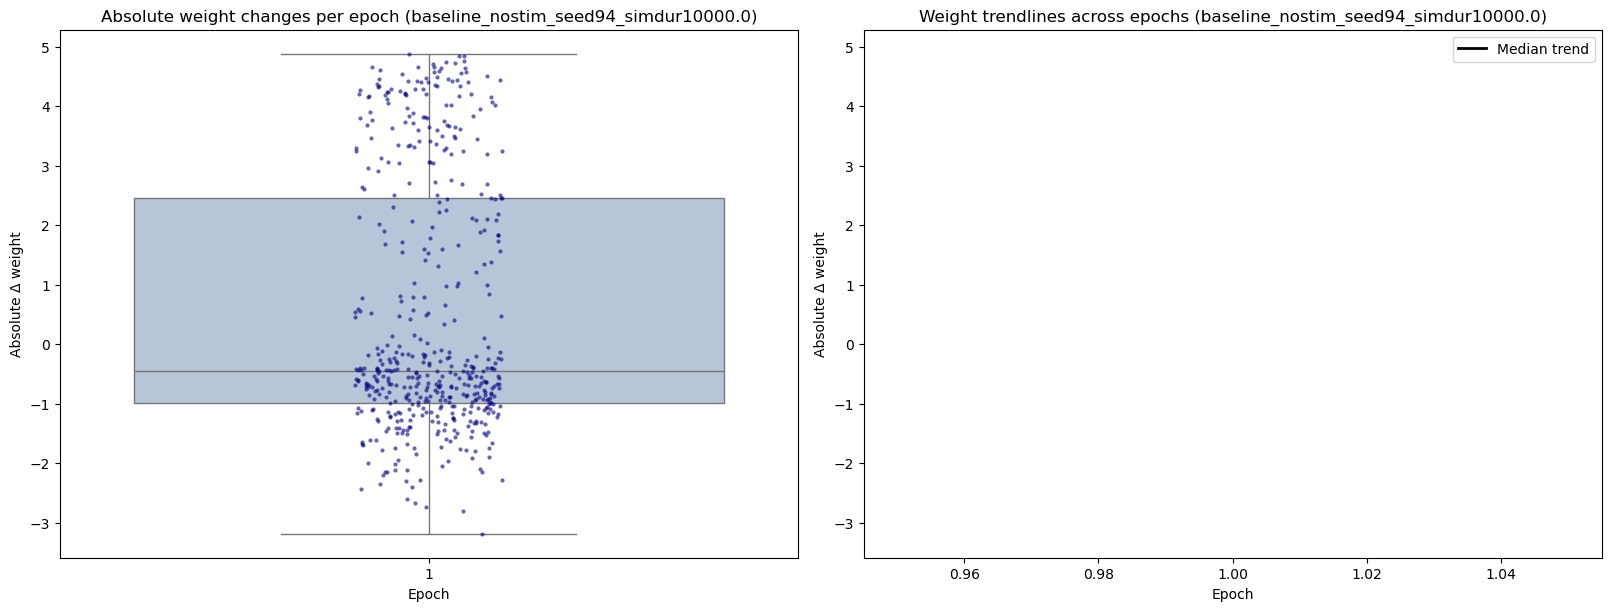

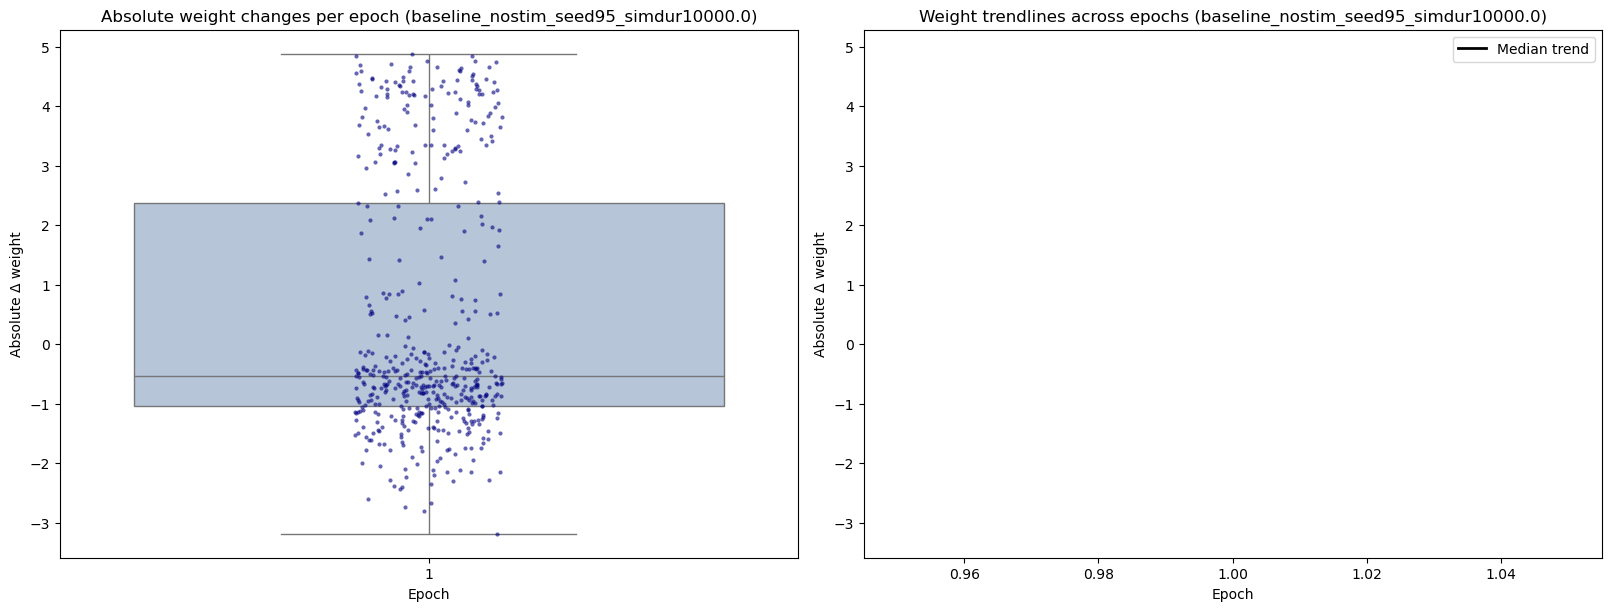

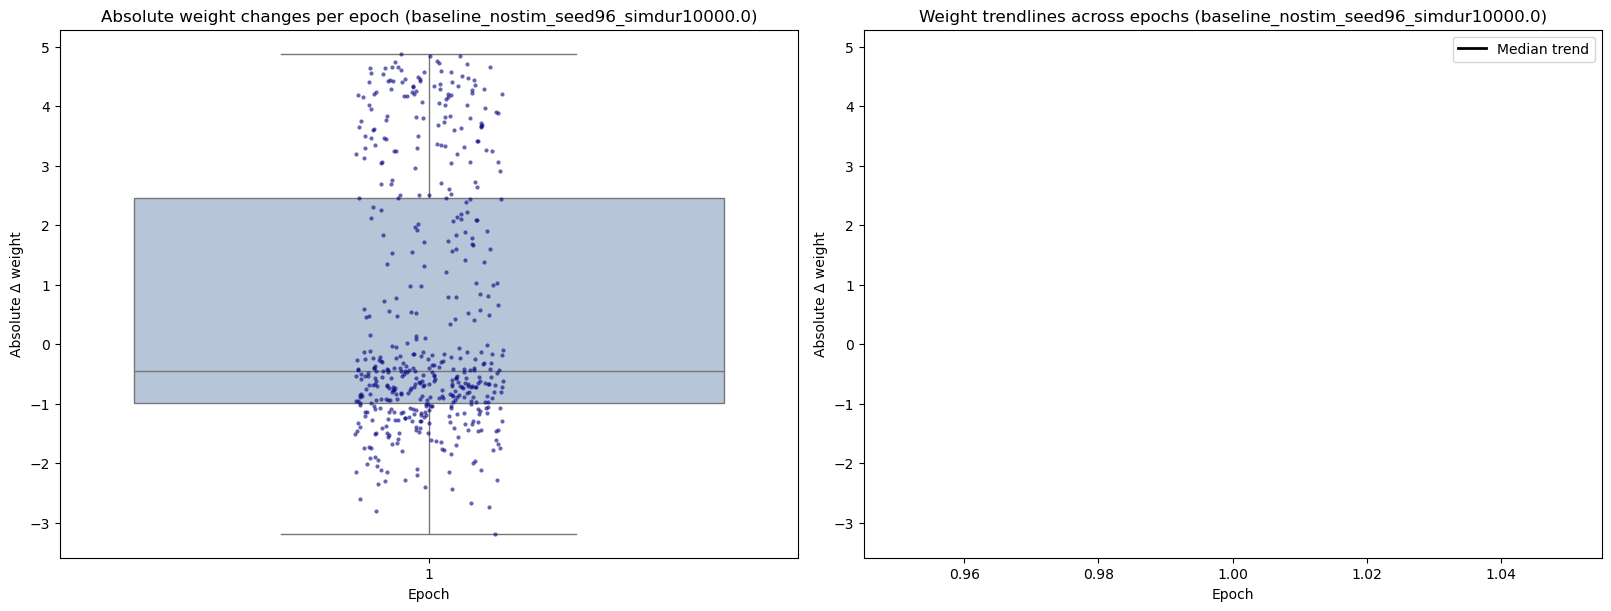

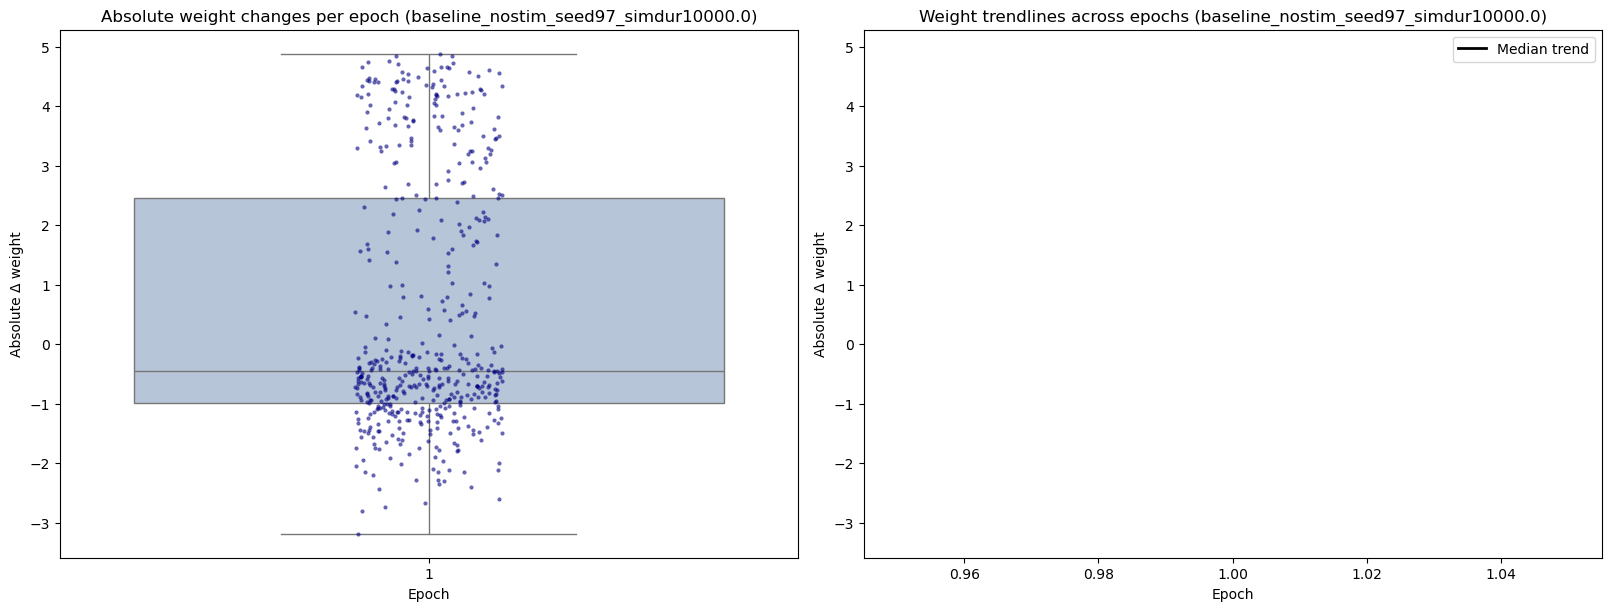

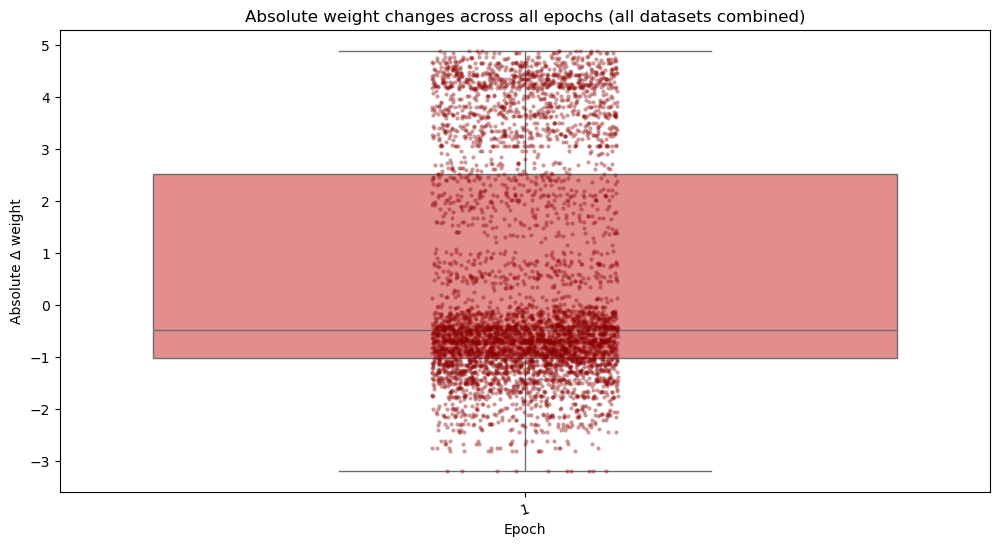

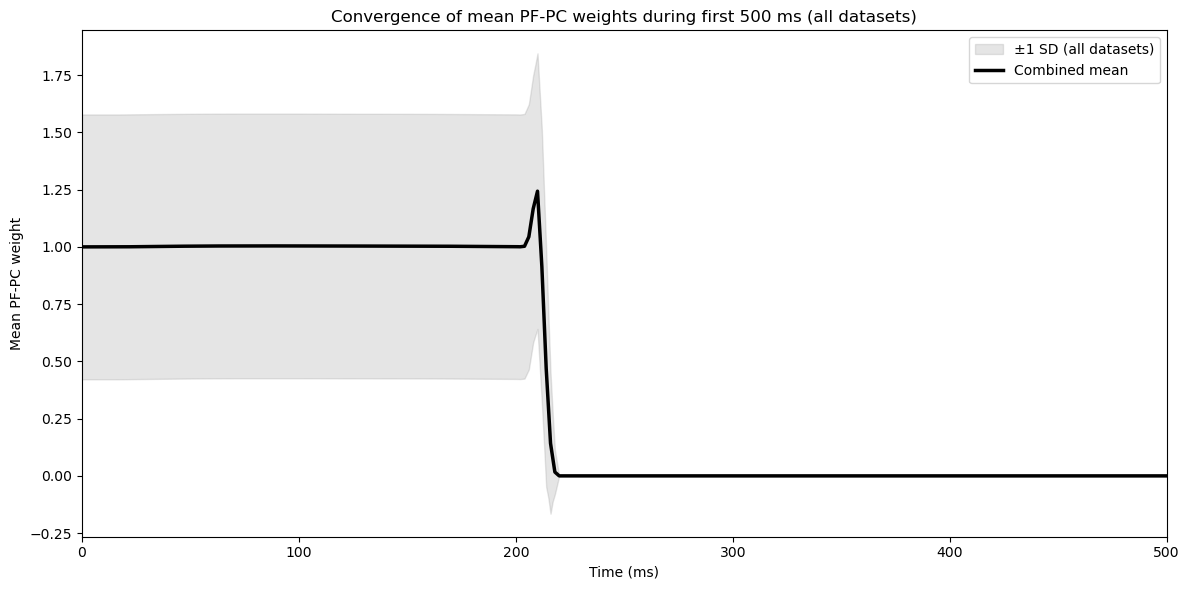

In [5]:
# Load baseline run datasets
datapaths = [job["run_path"] for job in base_repl_jobs]
chunk_size = 3_000.0  # ms

all_rows = []

for dataset in datapaths:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    
    weights = data['pfpc_weights']

    weights_p_chunk = weights[::int(chunk_size)]
    ts_chunks = ts[::int(chunk_size)]
    n_chunks = weights_p_chunk.shape[0]
    if n_chunks < 2:
        continue

    init_weights = weights_p_chunk[0]
    delta_weights_abs = np.diff(weights_p_chunk, axis=0)
    delta_weights_rel = delta_weights_abs / init_weights

    for epoch_idx in range(delta_weights_abs.shape[0]):
        for weight_idx in range(delta_weights_abs.shape[1]):
            all_rows.append({
                'dataset': label,
                'epoch': epoch_idx + 1,
                'weight_index': weight_idx,
                'abs_delta': delta_weights_abs[epoch_idx, weight_idx],
                'rel_delta': delta_weights_rel[epoch_idx, weight_idx],
                'time_ms': ts_chunks[epoch_idx + 1],
            })

all_df = pd.DataFrame(all_rows)

if all_df.empty:
    print("No epoch-level weight-change rows found; adjust chunk_size or dataset lengths.")
else:
    if 'dataset' not in all_df.columns:
        dataset_groups = [("all", all_df)]
    else:
        dataset_groups = all_df.groupby('dataset', sort=False)

    for label, group in dataset_groups:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

        sns.boxplot(
            x='epoch',
            y='abs_delta',
            data=group,
            ax=axes[0],
            color='lightsteelblue',
            whis=[0, 100],
            showfliers=False,
        )
        sns.stripplot(
            x='epoch',
            y='abs_delta',
            data=group,
            ax=axes[0],
            color='navy',
            alpha=0.6,
            size=3,
            jitter=True,
        )
        axes[0].set_title(f'Absolute weight changes per epoch ({label})')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Absolute Δ weight')

        epoch_order = sorted(group['epoch'].unique())
        for _, weight_group in group.groupby('weight_index'):
            weight_data = weight_group.sort_values('epoch')
            axes[1].plot(
                epoch_order,
                weight_data['abs_delta'],
                color='gray',
                alpha=0.15,
                linewidth=1,
            )

        median_by_epoch = group.groupby('epoch')['abs_delta'].median().reindex(epoch_order)
        axes[1].plot(epoch_order, median_by_epoch, color='black', linewidth=2, label='Median trend')
        axes[1].set_title(f'Weight trendlines across epochs ({label})')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Absolute Δ weight')
        axes[1].legend()

        plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='lightcoral',
    whis=[0, 100],
    showfliers=False,
)
sns.stripplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='darkred',
    alpha=0.4,
    size=3,
    jitter=True,
)
ax.set_title('Absolute weight changes across all epochs (all datasets combined)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Absolute Δ weight')
plt.xticks(rotation=15)
plt.show()

# Plot convergence toward a stable mean within the first 200 ms
window = 500 # ms
convergence_rows = []
for dataset in datapaths:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    weights = data['pfpc_weights']
    mask = ts <= window
    if np.sum(mask) == 0:
        continue

    ts_short = ts[mask]
    weights_short = weights[mask]

    for weight_idx in range(weights_short.shape[1]):
        for t, w in zip(ts_short, weights_short[:, weight_idx]):
            convergence_rows.append({
                'dataset': label,
                'weight_idx': weight_idx,
                'time_ms': t,
                'weight': w,
            })

convergence_df = pd.DataFrame(convergence_rows)
if not convergence_df.empty:
    plt.figure(figsize=(12, 6))
    
    # Plot individual weight trajectories (faintly)
    # for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        # plt.plot(group['time_ms'], group['weight'], alpha=0.01, color='gray')

    # Interpolate all individual weight trajectories to a common 1-ms grid
    time_grid = np.arange(0, window + 1, 1)
    interpolated = []
    for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        group_sorted = group.sort_values('time_ms')
        interp = np.interp(time_grid, group_sorted['time_ms'], group_sorted['weight'])
        interpolated.append(interp)

    combined_means = np.vstack(interpolated).mean(axis=0)
    combined_std = np.vstack(interpolated).std(axis=0)

    plt.fill_between(
        time_grid,
        combined_means - combined_std,
        combined_means + combined_std,
        color='gray',
        alpha=0.2,
        label='±1 SD (all datasets)',
    )
    plt.plot(time_grid, combined_means, color='black', linewidth=2.5, label='Combined mean')
    plt.title(f'Convergence of mean PF-PC weights during first {window} ms (all datasets)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Mean PF-PC weight')
    plt.xlim(0, window)
    plt.legend()
    plt.tight_layout()
    plt.show()

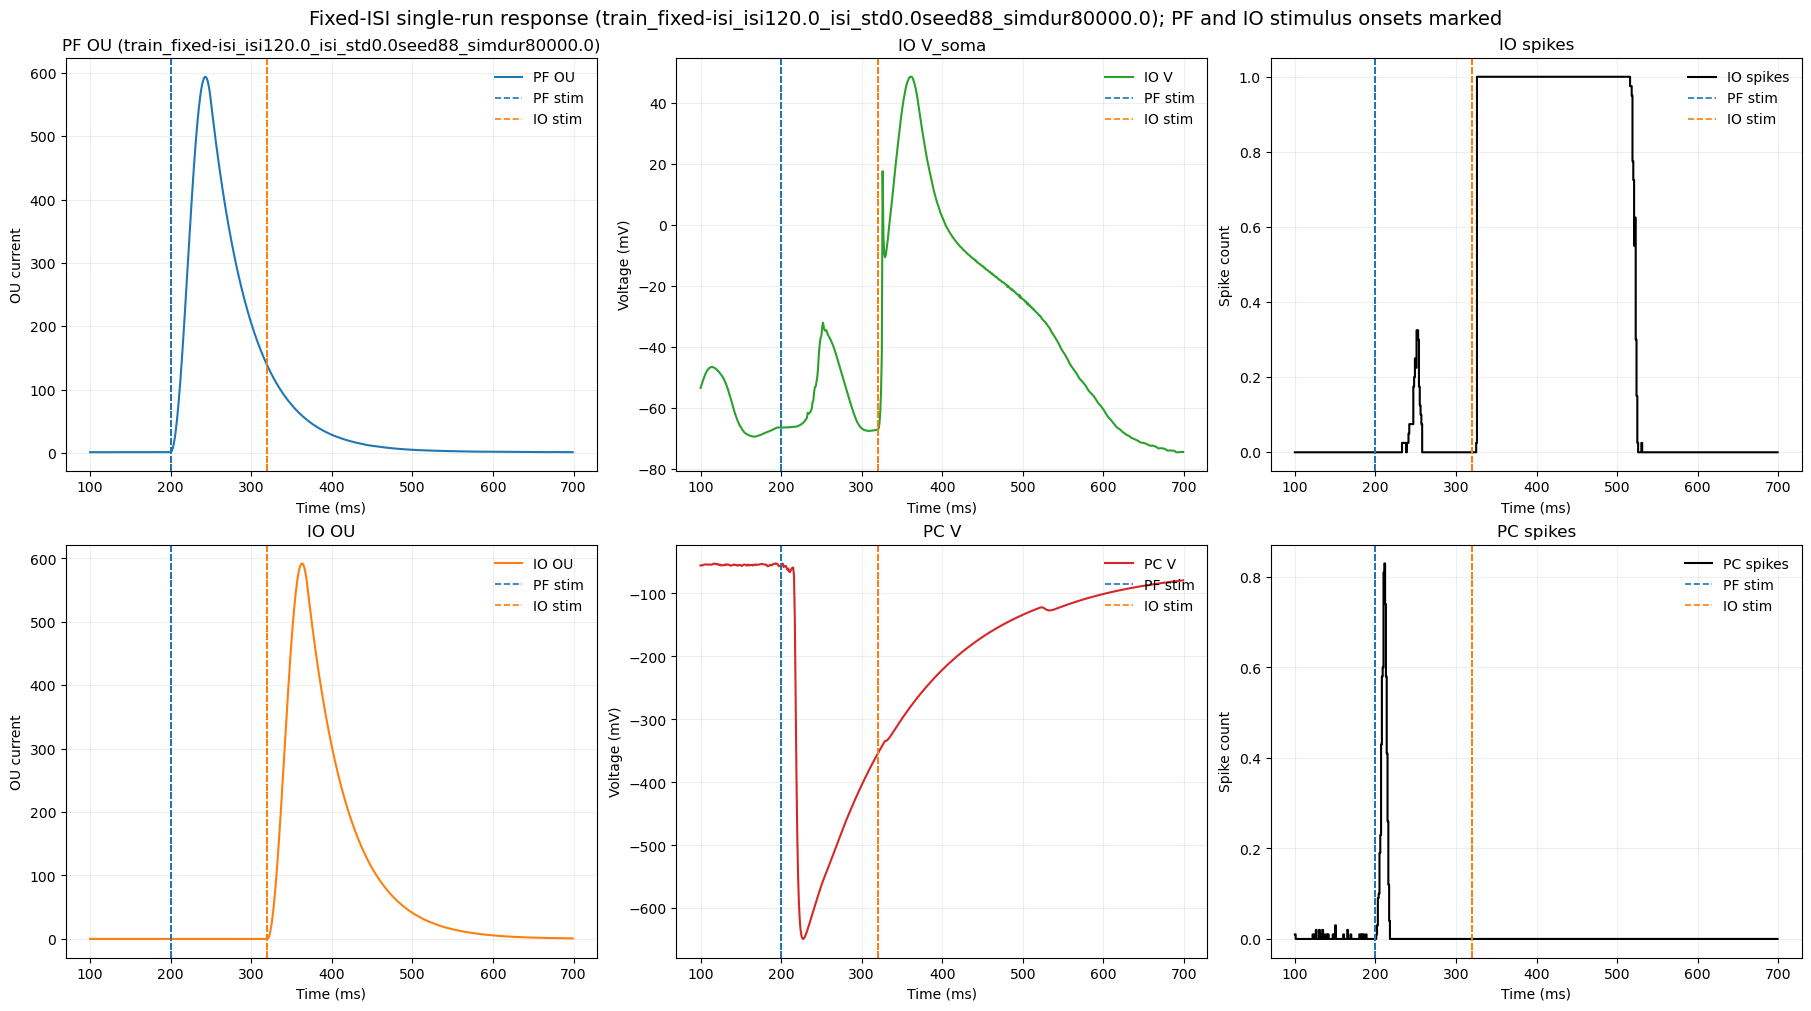

Loaded 20 fixed-ISI runs; plotting only train_fixed-isi_isi120.0_isi_std0.0seed88_simdur80000.0


In [24]:
# Build a dataset with all fixed-ISI runs, but plot only one run for inspection
fixed_isi_paths = [job["run_path"] for job in jobs_fixed_isi]
fixed_isi_runs = []

for dataset in fixed_isi_paths:
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = np.asarray(data.get("ts", np.arange(len(data["pf.I_OU"]))))
    run = {
        "dataset": dataset,
        "ts": ts,
        "pf_stim_start": np.asarray(data["stim_pf_start"]).ravel(),
        "io_stim_start": np.asarray(data["stim_io_start"]).ravel(),
        "pf_OU": np.asarray(data["pf.I_OU"]),
        "io_OU": np.asarray(data["io.I_OU"]),
        "pc_V": np.asarray(data["pc.V"]),
        "io_V": np.asarray(data["io.V_soma"]),
        "pc_spike": np.asarray(data["pc.spike"]),
        "io_spike": np.asarray(data["io.spike"]),
    }
    fixed_isi_runs.append(run)

selected_run = fixed_isi_runs[0]
selected_label = Path(selected_run["dataset"]).stem


def signal_mean_or_flat(arr):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return arr.reshape(-1)
    if arr.ndim > 1:
        return arr.mean(axis=1)
    return arr


def mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1):
    pf_lines = []
    io_lines = []

    for s in np.asarray(pf_starts).ravel():
        if t0 <= s <= t1:
            l = ax.axvline(s, color='tab:blue', linestyle='--', linewidth=1.2, alpha=0.8)
            pf_lines.append(l)

    for s in np.asarray(io_starts).ravel():
        if t0 <= s <= t1:
            l = ax.axvline(s, color='tab:orange', linestyle='--', linewidth=1.2, alpha=0.8)
            io_lines.append(l)

    if pf_lines:
        ax.plot([], [], color='tab:blue', linestyle='--', linewidth=1.2, label='PF stim')
    if io_lines:
        ax.plot([], [], color='tab:orange', linestyle='--', linewidth=1.2, label='IO stim')

    ax.legend(loc='upper right', frameon=False)

# Use a short window around the first stimulus onset for a clear single-run view
pf_starts = selected_run["pf_stim_start"]
io_starts = selected_run["io_stim_start"]
all_starts = np.concatenate([np.asarray(pf_starts).ravel(), np.asarray(io_starts).ravel()]) if (np.asarray(pf_starts).size or np.asarray(io_starts).size) else np.array([])

if all_starts.size > 0:
    event_time = float(all_starts.min())
    t0 = max(float(selected_run["ts"][0]), event_time - 100.0)
    t1 = min(float(selected_run["ts"][-1]), event_time + 600.0)
else:
    t0 = float(selected_run["ts"][0])
    t1 = float(selected_run["ts"][-1])

mask = (selected_run["ts"] >= t0) & (selected_run["ts"] <= t1)
ts = selected_run["ts"][mask]

pf_ou = signal_mean_or_flat(selected_run["pf_OU"][mask])
io_ou = signal_mean_or_flat(selected_run["io_OU"][mask])
pc_v = signal_mean_or_flat(selected_run["pc_V"][mask])
io_v = signal_mean_or_flat(selected_run["io_V"][mask])
pc_spikes = signal_mean_or_flat(selected_run["pc_spike"][mask])
io_spikes = signal_mean_or_flat(selected_run["io_spike"][mask])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

# 1: PF OU with both stimulus markers
ax = axes[0]
ax.plot(ts, pf_ou, color='tab:blue', linewidth=1.5, label='PF OU')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title(f'PF OU ({selected_label})')
ax.set_ylabel('OU current')
ax.set_xlabel('Time (ms)')

# 2: IO voltage with both stimulus markers
ax = axes[1]
ax.plot(ts, io_v, color='tab:green', linewidth=1.5, label='IO V')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title('IO V_soma')
ax.set_ylabel('Voltage (mV)')
ax.set_xlabel('Time (ms)')

# 3: IO spikes with both stimulus markers
ax = axes[2]
ax.plot(ts, io_spikes, drawstyle='steps-post', color='black', linewidth=1.5, label='IO spikes')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title('IO spikes')
ax.set_ylabel('Spike count')
ax.set_xlabel('Time (ms)')

# 4: IO OU with both stimulus markers
ax = axes[3]
ax.plot(ts, io_ou, color='tab:orange', linewidth=1.5, label='IO OU')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title('IO OU')
ax.set_ylabel('OU current')
ax.set_xlabel('Time (ms)')

# 5: PC voltage with both stimulus markers
ax = axes[4]
ax.plot(ts, pc_v, color='tab:red', linewidth=1.5, label='PC V')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title('PC V')
ax.set_ylabel('Voltage (mV)')
ax.set_xlabel('Time (ms)')

# 6: PC spikes with both stimulus markers
ax = axes[5]
ax.plot(ts, pc_spikes, drawstyle='steps-post', color='black', linewidth=1.5, label='PC spikes')
mark_stimulus_onsets(ax, pf_starts, io_starts, t0, t1)
ax.set_title('PC spikes')
ax.set_ylabel('Spike count')
ax.set_xlabel('Time (ms)')

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle(f'Fixed-ISI single-run response ({selected_label}); PF and IO stimulus onsets marked', fontsize=14)
plt.show()

print(f'Loaded {len(fixed_isi_runs)} fixed-ISI runs; plotting only {selected_label}')
